In [4]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


# function to scale the y-axis data between 0 and 1
def scale_y(data, scale=True):
    """
    Scales the y-axis data between 0 and 1.
    
    Parameters:
    data (array-like): The y-axis data to be scaled.
    
    Returns:
    array-like: Scaled y-axis data.
    """
    if not scale:
        return data
    
    return (data - np.min(data)) / (np.max(data) - np.min(data))



<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/var/folders/2c/v1gf79kx5qz4k9m6pz64n50c0000gn/T/ipykernel_19355/1587781735.py:13: SyntaxWarning: invalid escape sequence '\m'
  label = f'{power} $\mu$W'  # Only the power value with units


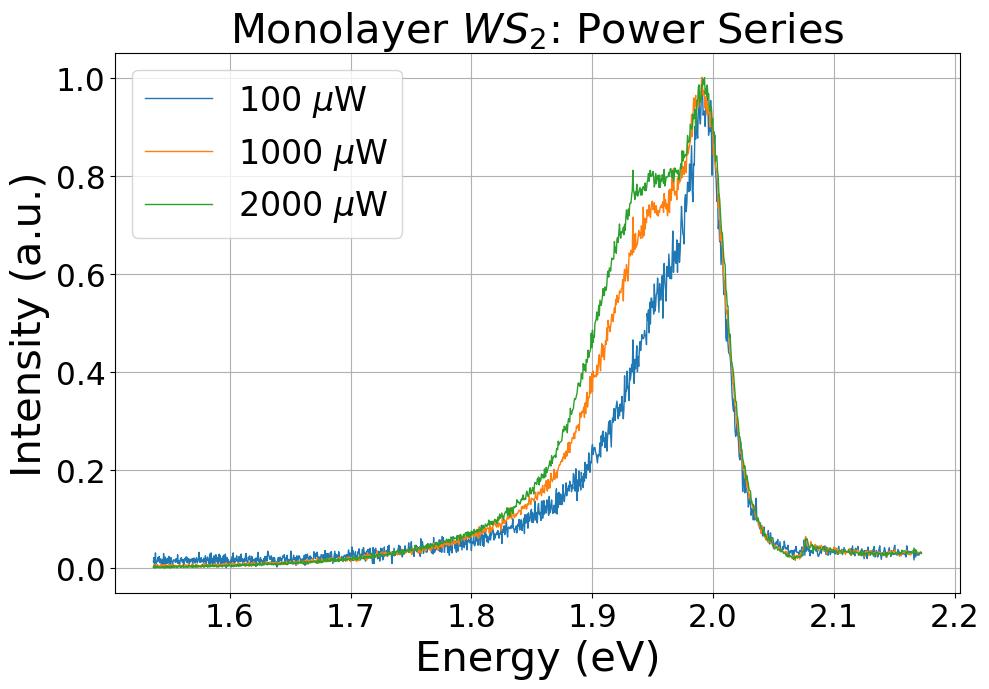

In [5]:
import glob as glob

powers = [100, 1000, 2000]
scale = True  # Set to True to scale y-axis data

plt.figure(figsize=(10, 7))
fontsize = 30


for power in powers:
    df = pd.read_csv(glob.glob(f'pl-data-2/power{power}uw*.csv')[0], delimiter='\t')
    
    label = f'{power} $\mu$W'  # Only the power value with units
    linewidth = 1 if power in [100, 1000, 2000] else 1
    color = None if power in [100, 1000, 2000] else "black"
    
    plt.plot(df['Wavelength'], scale_y(df['Intensity'], scale), label=label, linewidth=linewidth, color=color)

plt.xlabel('Energy (eV)', fontsize=fontsize)
plt.ylabel('Intensity (counts)' if not scale else 'Intensity (a.u.)', fontsize=fontsize)
plt.title('Monolayer $WS_2$: Power Series', fontsize=fontsize)
plt.tick_params(labelsize=fontsize * 0.75)
plt.legend(fontsize=fontsize * 0.8)
plt.grid()

plt.tight_layout()
plt.show()

# powers = [100, 600, 1000, 1500, 2000]

# scale = False  # Set to True to scale y-axis data

# plt.figure(figsize=(10, 6))

# for power in powers:
#     df = pd.read_csv(glob.glob(f'pl-data-2/power{power}uw*.csv')[0], delimiter='\t')
    
#     if power == 100 or power == 1000 or power == 2000:
#         plt.plot(df['Wavelength'], scale_y(df['Intensity'], scale), label=f'Power={power}$\mu$W', linewidth = 1)
#     else:
#         plt.plot(df['Wavelength'], scale_y(df['Intensity'], scale), label=f'Power={power}$\mu$W', linewidth = 0.5, color= "black")
    
# plt.xlabel('Photon Energy (eV)')
# plt.ylabel('Intensity (a.u.)')
# plt.title('Photoluminescence Spectra for Monolayer WS2: Power Series')
# plt.legend()
# plt.grid()

Observations:
- Increasing power resulted in increased intensity counts, as expected
- The peak is asymmetric in nature, and increased power makes it more so. This emergent second peak is TRION PEAK.
- Scaled Plot shows no significant change in the position of the main peak, but a slight red shift in the trion peak.
- Small artifact appears between 2.05-2.1 eV, cause unknown.



<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/var/folders/2c/v1gf79kx5qz4k9m6pz64n50c0000gn/T/ipykernel_19355/1269352274.py:39: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Excitation Power ($\mu$W)', fontsize=14)


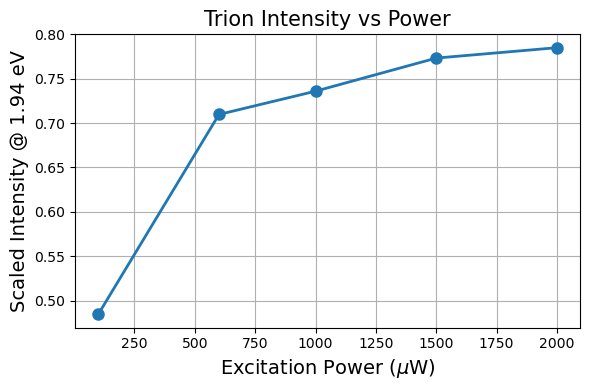

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Function to scale between 0 and 1
def scale_y(data, scale=True):
    if not scale:
        return data
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# Parameters
powers = [100, 600, 1000, 1500, 2000]
target_energy = 1.94  # eV
window = 0.005  # +/- range for matching
scale = True

# Store extracted intensities
trion_intensities = []

for power in powers:
    df = pd.read_csv(glob.glob(f'pl-data-2/power{power}uw*.csv')[0], delimiter='\t')
    
    energy = df['Wavelength'].values
    intensity = scale_y(df['Intensity'].values, scale)

    # Mask around target energy
    mask = (energy > target_energy - window) & (energy < target_energy + window)
    if np.any(mask):
        trion_intensity = np.max(intensity[mask])
    else:
        trion_intensity = np.nan  # in case data is missing near 1.95 eV

    trion_intensities.append(trion_intensity)

# Plotting
plt.figure(figsize=(6, 4))
plt.plot(powers, trion_intensities, 'o-', linewidth=2, markersize=8)
plt.xlabel('Excitation Power ($\mu$W)', fontsize=14)
plt.ylabel('Scaled Intensity @ 1.94 eV', fontsize=14)
plt.title('Trion Intensity vs Power', fontsize=15)
plt.grid(True)
# plt.yscale("log")
plt.tight_layout()
plt.show()